# CS1090a Final Project Milestone 4

### Project  Title: Comparing Linear and Polynomial Models’ Ability to Predict Blood Lactate Levels with Metabolic and Biomechanical Indicators  

**Group Members:**

- David Soucie(sirob7007@gmail.com)

- Eva Harris (evaharris@college.harvard.edu)

- Ethan Aidam (eaidam@college.harvard.edu)

- Sam Burgess (sburgess@college.harvard.edu)

- Shay Li (sineadli@college.harvard.edu)


## Table of Contents
* [1 - Problem Statement](#1---problem-statement)

* [2 - Pre-Processing](#2---pre-processing)
    * [2.1 - Import Libraries](#21---import-libraries)
    * [2.2 - Data Loading](#22---data-loading)

* [3 - Data Description](#3---data-description)
    * [3.1 - Dataset Qualities](#31---dataset-qualities)
        * [3.1.1 - Combined Dataset](#311---combined-dataset)
        * [3.1.2 - By Individual Day](#312---by-individual-day)
        * [3.1.3 - Conclusions of Qualities Across Days](#313---conclusions-of-qualities-across-days)
    * [3.2 - Histograms](#32---histograms)
    * [3.3 - Correlation Plots](#33---correlation-plots)
        * [3.3.1 - Combined Dataset](#331---combined-dataset)
        * [3.3.2 - Individual Days](#332---individual-days)
    * [3.4 - Clustering Plots](#34---clustering-plots)
    * [3.5 - Findings Summary](#35---findings-summary)

* [4 - Baseline Model](#4---baseline-model)
    * [4.1 - Simple Linear Regression](#41---simple-linear-regression)
    * [4.2 - Multiple Linear Regression](#42---multiple-linear-regression)
    * [4.3 - Model with Interaction Terms](#43---model-with-interaction-terms)
    * [4.4 - Polynomial Term (squared terms)](#44---polynomial-term-squared-terms)
    * [4.5 - Model Selection Comparison](#45---model-selection-comparison)
        * [4.5.1 - Assumption Checking for Linear Models](#451---assumption-checking-for-linear-models)

* [5 - Prediction Models](#5---prediction-models)
    * [5.1 - Baseline Predictive Model](#51---baseline-predictive-model)
    * [5.2 - LASSO Regression](#52---lasso-regression)
    * [5.3 - RIDGE Regression](#53---ridge-regression)
    * [5.4 - Random Forest](#54---random-forest)


## 1 - Problem Statement

Understanding the factors influencing blood lactate threshold is vital for assessing athletic performance and designing personalized training. 
Traditional linear models may oversimplify the nonlinear relationships between biomechanical variables (e.g., gait dynamics) and metabolic measures (VO₂, EE). 

Our project explores whether polynomial regression better predicts lactate threshold, and uses time series modeling to capture trends in blood lactate across exercise intensities. We have two main goals for which we are attempting to evaluate the models:
    - How well do models predict the current Blood Lactate level, given several other easier to measure features?
    - How well do models predict a future Blood Lactate level, based on other easier to measure features?

The overall goal of these evaluations is to determine whether future methods for predicting blood lactate, both in the present and future, should presume a linear or non-linear relationship between the predictors and target. If the best performing model is linear, a linear relationship can be determined, whereas if the best performing model is polynomial, a non-linear relationship can be determined. Best performance will be measured using raw accuracy, and roc-auc.

## 2 - Pre-Processing

### 2.1 - Import Libraries

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
# pandas tricks for better display
pd.options.display.max_columns = 50  
pd.options.display.max_rows = 500     
pd.options.display.max_colwidth = 100
pd.options.display.precision = 3

## 3 - Data Description

We will use a dataset of "Blood Lactate Concentration During Cycling High Intensity Interval Training". 
This data was collected from a single high performance athlete being tested for VO_2 maximum using an indoor cycler across 3 days of testing, using various wearable devices and monitors. Each test involved the exact same workout, that being a combination of low intensity baseline activity, with specific periods of high intensity exercise.


The data was entirely complete, with no null values. Most values are floats, though a few values are integers; all are numeric. Each row of the dataset is a specific second of the training session, and each feature is a biomechanical observation specific to that second.

In order to evaluate whether the data behaves differently across days of training, 4 datasets are created. The first dataset, "df", is a combined dataset of all 3 days of the training session, with a new column of "Day" added to group the individual days. For convenient use, 3 other datasets are also created, "day_[n]_df", for $n \in [1, 3]$ ,  corresponding to each day of the training session.

The dataset includes the following 9 features, all of which with 8818 entries:

| Feature      | Description                                                    | Units / Notes      |
| ------------ | -------------------------------------------------------------- | ------------------ |
| `time`       | Second of the test when the measurement was taken              | seconds            |
| `power`      | Cycling power output                                           | watts              |
| `VO2`        | Oxygen consumption                                             | O₂/min             |
| `cadence`    | Cycling cadence (revolutions per minute)                       | RPM                |
| `lactate`    | Blood lactate concentration                                    | mmol/L             |
| `rf`         | Respiratory frequency                                          | breaths per minute |
| `heart_rate` | Heart rate                                                     | beats per minute   |
| `saturation` | Blood oxygen saturation                                        | percentage (%)     |
| `day`        | Day on which the data was collected (pre-processing indicator) | 1, 2, or 3         |


### Data Loading

In [9]:
day1_df = pd.read_csv("data/day1_lactate_challenge.csv")
day2_df = pd.read_csv("data/day2_lactate_challenge.csv")
day3_df = pd.read_csv("data/day3_lactate_challenge.csv")


day1_df["day"] = 1
day2_df["day"] = 2
day3_df["day"] = 3

df = pd.concat([day1_df, day2_df, day3_df], ignore_index=True)
df.head()

,time,power,VO2,cadence,lactate,rf,heart_rate,saturation,day
0,1,0,313.460,0,0.749,18.445,52.5,99.0,1
1,2,0,214.150,0,0.748,17.962,53.0,99.0,1
2,3,0,114.840,0,0.747,17.480,53.5,99.0,1
3,4,0,15.532,0,0.746,16.997,54.0,99.0,1
4,5,0,247.580,0,0.745,16.748,54.0,99.0,1


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8818 entries, 0 to 8817
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   time        8818 non-null   int64  
 1   power       8818 non-null   int64  
 2   VO2         8818 non-null   float64
 3   cadence     8818 non-null   int64  
 4   lactate     8818 non-null   float64
 5   rf          8818 non-null   float64
 6   heart_rate  8818 non-null   float64
 7   saturation  8818 non-null   float64
 8   day         8818 non-null   int64  
dtypes: float64(5), int64(4)
memory usage: 620.1 KB


### 3.1 - Dataset Qualities
#### 3.1.1 - Combined Dataset

We created a helper function defined as `calc_outliers`, which is designed to calculate the numner of outliers present in each feature. Our `Outliers` count was determined based upon z-score.
### Dataset Qualities

The qualities used to analyze the dataset are:
    - Mean: Mean of all columns
    - Standard Deviation: Variance of all columns
    - Maximum: The maximum value observed in the column
    - Minimum: The minimum value observed in the column
    - Outliers: The total number of observations in the column that exceed the z-score threshold of 2.5

In [ ]:
# Function takes in a dataframe, then outputs a tall dataframe with a single column containing the outlier count for each column of the inputted dataframe, and each row representing a column of the inputted dataframe
def calc_outliers(in_df):
    output = pd.DataFrame()
    for column in in_df.columns:
        z_score = np.abs(stats.zscore(in_df[column]))
        output[column] = [in_df[z_score > 2.5][column].count()]
    return pd.melt(output, value_vars = in_df.columns, var_name = "index", value_name = "Outliers").set_index("index")

#### Qualities - Entire Dataset

In [ ]:
pd.DataFrame({"Null count" : df.isnull().sum(), 
              "Mean" : df.mean(), 
              "Standard Deviation" : df.std(), 
              "Maximum" : df.max(), 
              "Minimum" : df.min(),
              "Outliers": [val[0] for val in calc_outliers(df).values]})

,Null count,Mean,Standard Deviation,Maximum,Minimum,Outliers
time,0,1495.002,887.722,3238.000,1.000,0
power,0,130.438,113.461,778.000,0.000,184
VO2,0,2304.235,1013.736,4869.200,2.415,1
cadence,0,75.841,39.749,170.000,0.000,0
lactate,0,5.332,3.215,11.160,0.580,0
rf,0,27.014,7.453,75.483,4.481,181
heart_rate,0,120.489,29.547,177.000,48.000,0
saturation,0,96.441,1.649,99.000,91.000,17
day,0,1.905,0.794,3.000,1.000,0


#### 3.1.2 - By Individual Day

Next, we decided to parse the individual days to get a picture regarding the data in each day. By doing this we can better understand the variation between the days and how this may affect our analysis later in this notebook.

In [ ]:
# Day 1 Qualities
pd.DataFrame({"Null count": day1_df.isnull().sum(),
              "Mean": day1_df.mean(),
              "Standard Deviation": day1_df.std(),
              "Maximum": day1_df.max(),
              "Minimum": day1_df.min(),
              "Outliers": [val[0] for val in calc_outliers(day1_df).values]})

/var/folders/3h/3bv2b5250hb1xgqdq_m732kw0000gn/T/ipykernel_16060/1731444044.py:5: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_score = np.abs(stats.zscore(in_df[column]))


,Null count,Mean,Standard Deviation,Maximum,Minimum,Outliers
time,0,1619.500,934.874,3238.000,1.000,0
power,0,129.608,97.694,350.000,0.000,0
VO2,0,2140.876,1034.657,4788.300,15.532,2
cadence,0,70.748,41.793,112.000,0.000,0
lactate,0,4.593,2.865,9.790,0.630,0
rf,0,24.898,6.376,75.483,6.920,85
heart_rate,0,121.027,31.156,177.000,49.000,0
saturation,0,96.981,1.352,99.000,94.000,0
day,0,1.000,0.000,1.000,1.000,0


Day 2

In [ ]:
# Day 2 Qualities
pd.DataFrame({"Null count" : day2_df.isnull().sum(),
              "Mean" : day2_df.mean(), 
              "Standard Deviation" : day2_df.std(), 
              "Maximum" : day2_df.max(), 
              "Minimum" : day2_df.min(),
             "Outliers": [val[0] for val in calc_outliers(day2_df).values]})

/var/folders/3h/3bv2b5250hb1xgqdq_m732kw0000gn/T/ipykernel_16060/1731444044.py:5: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_score = np.abs(stats.zscore(in_df[column]))


,Null count,Mean,Standard Deviation,Maximum,Minimum,Outliers
time,0,1590.500,918.131,3180.000,1.000,0
power,0,145.148,111.674,596.000,0.000,57
VO2,0,2493.999,939.473,4869.200,15.086,25
cadence,0,80.304,35.378,145.000,0.000,0
lactate,0,4.399,2.180,7.630,0.580,0
rf,0,27.894,6.684,56.075,4.481,70
heart_rate,0,123.464,26.770,166.000,51.000,125
saturation,0,95.436,1.478,99.000,91.000,1
day,0,2.000,0.000,2.000,2.000,0


Day 3

In [ ]:
# Day 3 Qualities
pd.DataFrame({"Null count" : day3_df.isnull().sum(),
              "Mean" : day3_df.mean(), 
              "Standard Deviation" : day3_df.std(), 
              "Maximum" : day3_df.max(), 
              "Minimum" : day3_df.min(),
              "Outliers": [val[0] for val in calc_outliers(day3_df).values]})

/var/folders/3h/3bv2b5250hb1xgqdq_m732kw0000gn/T/ipykernel_16060/1731444044.py:5: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  z_score = np.abs(stats.zscore(in_df[column]))


,Null count,Mean,Standard Deviation,Maximum,Minimum,Outliers
time,0,1200.500,692.965,2400.000,1.000,0
power,0,112.067,131.468,778.000,0.000,123
VO2,0,2273.196,1038.358,4561.700,2.415,0
cadence,0,76.800,41.585,170.000,0.000,0
lactate,0,7.564,3.708,11.160,0.610,0
rf,0,28.701,8.953,63.158,9.624,40
heart_rate,0,115.822,30.254,161.000,48.000,0
saturation,0,97.044,1.593,99.000,93.000,13
day,0,3.000,0.000,3.000,3.000,0


#### 3.1.3 - Conclusions of Qualities Analysis

Some variation can be seen in the mean and standard deviation of each field on a per-day basis. However, unless these differences are also reflected in the correlations for each feature, it should not affect the results significantly.

What could more significnatly affect results is the high discrepency between mean, variance, and standard deviation between the different features, as well as a number of outliers within the data. Since our testing will go on to include polynomial regression at higher orders, scaling will be needed to prevent numerical instability. In addition, outliers will need to be removed, to prevent distortion of the dataset.
As a result, all values outside of the z_score threshold are removed and replaced with the column mean.
Then a Scaler is used to normalize these values to ensure that the differences do not bias the model or compromise potential conclusions. In order to preserve data consistency, the scaler is applied to the dataset with all 3 days, with all subsequent analysis on individual days using the data from the main, scaled dataframe.
For visualization purposes, the original unscaled dataframe will also be preserved for later use in the notebook.

In [ ]:
# Remove outliers
for column in df:
    z_score = np.abs(stats.zscore(df[column]))
    print(df[z_score > 2.5])
    mean = df[z_score <= 2.5][column].mean()
    if np.isnan(mean):
        mean = 0
    df.loc[z_score > 2.5, column] = mean

Empty DataFrame
Columns: [time, power, VO2, cadence, lactate, rf, heart_rate, saturation, day]
Index: []
        time  power     VO2  cadence  lactate      rf  heart_rate  saturation  \
5798  2561.0    434  2089.7      106    4.431  30.457       115.0        94.0   
5799  2562.0    480  2097.5      113    4.428  29.694       115.0        94.0   
5800  2563.0    480  2105.3      115    4.425  28.932       115.0        94.0   
5801  2564.0    461  2113.1      113    4.423  28.169       115.0        93.0   
5802  2565.0    449  2023.9      112    4.420  27.185       115.0        93.0   
5803  2566.0    444  1934.6      110    4.417  26.201       115.0        93.0   
5804  2567.0    447  2017.3      110    4.415  25.653       115.5        93.0   
5805  2568.0    459  2099.9      112    4.412  25.105       116.0        93.0   
5806  2569.0    473  2137.0      113    4.409  26.975       116.0        93.0   
5807  2570.0    474  2174.1      114    4.407  28.846       116.0        93.0   
5808

/var/folders/3h/3bv2b5250hb1xgqdq_m732kw0000gn/T/ipykernel_16060/2005204345.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '1495.0023814924018' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[z_score > 2.5, column] = mean
/var/folders/3h/3bv2b5250hb1xgqdq_m732kw0000gn/T/ipykernel_16060/2005204345.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '120.71426916840399' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[z_score > 2.5, column] = mean
/var/folders/3h/3bv2b5250hb1xgqdq_m732kw0000gn/T/ipykernel_16060/2005204345.py:8: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '75.84146064867316' has dtype incompatible with int64, please explicitly cas

In [ ]:
# Scale data, then split back into per-day datasets
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)
df_u = df.copy()
day1_df_u = day1_df.copy()
day2_df_u = day2_df.copy()
day3_df_u = day3_df.copy()

df = pd.DataFrame(scaler.fit_transform(df), columns = df.columns)
day1_df = df[df["day"] == df.iloc[0]["day"]]
day2_df = df[df["day"] == df.iloc[4000]["day"]]
day3_df = df[df["day"] == df.iloc[8000]["day"]]

df.head()

,time,power,VO2,cadence,lactate,rf,heart_rate,saturation,day
0,-1.683,-1.326,-1.964,-1.908,-1.425,-1.239,-2.301,1.558,-1.14
1,-1.682,-1.326,-2.062,-1.908,-1.426,-1.312,-2.284,1.558,-1.14
2,-1.681,-1.326,-2.160,-1.908,-1.426,-1.385,-2.267,1.558,-1.14
3,-1.680,-1.326,-2.258,-1.908,-1.426,-1.457,-2.250,1.558,-1.14
4,-1.679,-1.326,-2.029,-1.908,-1.426,-1.495,-2.250,1.558,-1.14


### 3.2 - Histograms

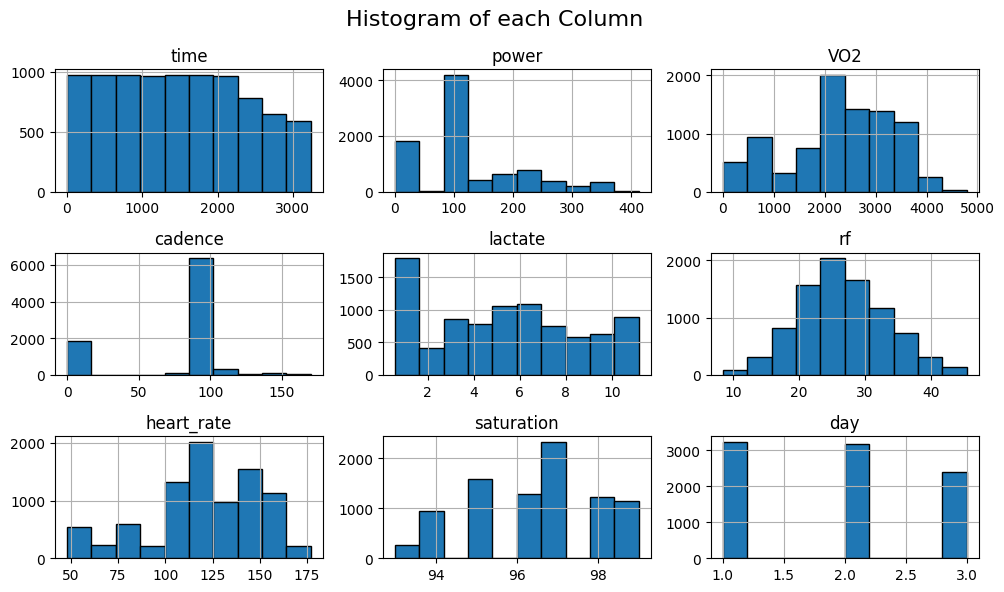

In [ ]:
df_u.hist(figsize=(10, 6), bins = 10, edgecolor = "black")

plt.suptitle("Histogram of each Column", fontsize = 16)
plt.tight_layout()
plt.show()

No noteworthy concerns from the histogram, though some features do give insight on the nature of the performance. The athlete held a similar cadence and power level for the majority of the test, but with occasional bursts of higher levels of power and speed. This matches the typical process for VO2 max testing, with a default steady pace followed by bursts of max effort at specific intervals. 

Notably, time distribution shows that each session did not have the exact same total training time, since certain time values are less represented than others.

### 3.3 - Correlation Plots

([<matplotlib.axis.YTick at 0x133697e50>,
 [Text(0, 0, 'time'),
  Text(0, 1, 'power'),
  Text(0, 2, 'VO2'),
  Text(0, 3, 'cadence'),
  Text(0, 4, 'lactate'),
  Text(0, 5, 'rf'),
  Text(0, 6, 'heart_rate'),
  Text(0, 7, 'saturation'),
  Text(0, 8, 'day')])

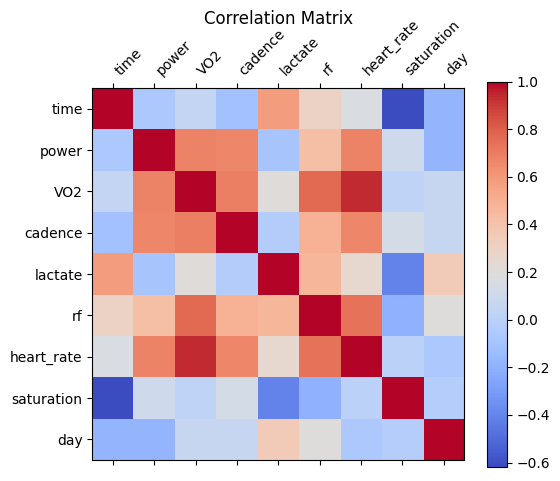

In [ ]:
corr = df.corr(numeric_only=True)
fig, ax = plt.subplots(figsize=(6, 5))
cax = ax.matshow(corr, cmap="coolwarm")

plt.title("Correlation Matrix", y=1.15)
plt.colorbar(cax)
plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="left")
plt.yticks(range(len(corr.columns)), corr.columns)

#### 3.3.1 - Combined Dataset

In [ ]:
# Takes in an input of a correlation matrix, and returns a dataset that neatly displays every single correlation, sorted from highest correlated interaction to lowest.
def display_corr(corr):
    corr_flat = (
        corr.unstack()
             .reset_index()
             .rename(columns={'level_0': 'Variable 1',
                              'level_1': 'Variable 2',
                              0: 'Correlation'})
    )
    corr_flat = corr_flat[corr_flat['Variable 1'] != corr_flat['Variable 2']]
    corr_flat = corr_flat.drop_duplicates(subset=['Correlation'])
    
    corr_flat = corr_flat.sort_values(by='Correlation', ascending=False)
    return corr_flat

display_corr(corr)

,Variable 1,Variable 2,Correlation
24,VO2,heart_rate,0.938
23,VO2,rf,0.764
51,rf,heart_rate,0.738
21,VO2,cadence,0.694
11,power,VO2,0.683
15,power,heart_rate,0.682
12,power,cadence,0.667
33,cadence,heart_rate,0.664
4,time,lactate,0.581
32,cadence,rf,0.494


#### 3.3.2 - Individual Days

Day 1

In [ ]:
display_corr(day1_df.corr())

,Variable 1,Variable 2,Correlation
24,VO2,heart_rate,0.950
11,power,VO2,0.848
15,power,heart_rate,0.825
4,time,lactate,0.807
12,power,cadence,0.770
51,rf,heart_rate,0.755
23,VO2,rf,0.750
21,VO2,cadence,0.639
33,cadence,heart_rate,0.614
14,power,rf,0.590


Day 2

In [ ]:
display_corr(day2_df.corr())

,Variable 1,Variable 2,Correlation
24,VO2,heart_rate,0.934
4,time,lactate,0.848
51,rf,heart_rate,0.748
23,VO2,rf,0.732
21,VO2,cadence,0.686
33,cadence,heart_rate,0.645
11,power,VO2,0.613
12,power,cadence,0.580
15,power,heart_rate,0.573
41,lactate,rf,0.541


Day 3

In [ ]:
display_corr(day3_df.corr())

,Variable 1,Variable 2,Correlation
24,VO2,heart_rate,0.957
12,power,cadence,0.849
23,VO2,rf,0.825
51,rf,heart_rate,0.812
33,cadence,heart_rate,0.769
21,VO2,cadence,0.766
4,time,lactate,0.711
15,power,heart_rate,0.667
11,power,VO2,0.657
32,cadence,rf,0.617


Via the correlation matrix, we can see a few notably strong correlations, those being VO2 with heart rate and respiration, respiration with heart rate, and VO2 with cadence. A relatively strong negative correlation can also be seen with time and saturation.

However, we can also see significant variation in the correlations between specific features, even though no significant correlations between the specific day and each feature can be seen. This suggests that the athlete may have different performance circumstances across the training session of each day in the dataset, potentially due to factors like sleep, fatigue, and lifestyle influence, all of which lack metrics in this dataset.
No signfi

Regardless, no significant correlations between the specific day and each feature can be seen. For this reason, a model trained using a dataset of the entire test set can be trusted to be reasonably accurate depiction of predictive ability, so long as it doesn't perform significantly weaker on any one day of the test or has large variance in its predictive performance across days. 


### 3.4 - Clustering Plots

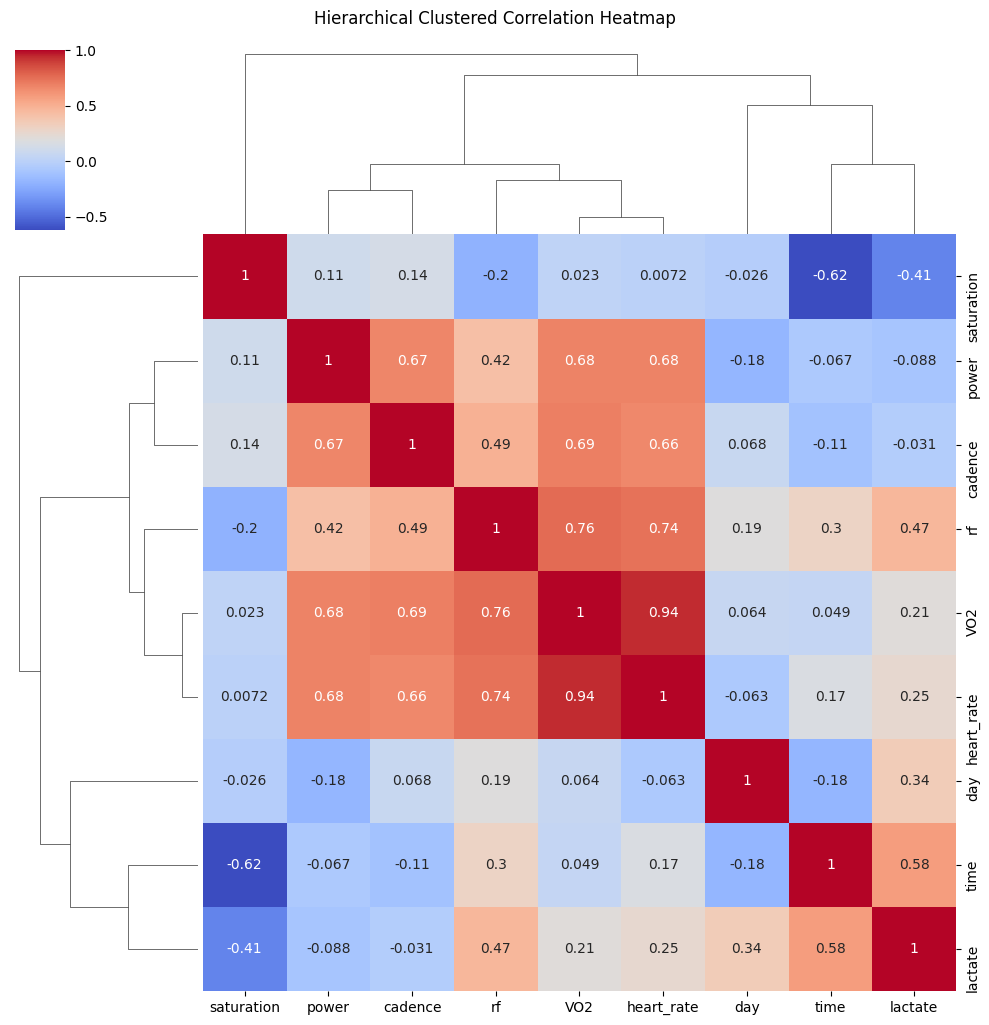

In [ ]:
sns.clustermap(corr, cmap="coolwarm", annot=True)

plt.suptitle("Hierarchical Clustered Correlation Heatmap", y=1.02)
plt.show()

The clustermap shows the similar effects of the correlations showed, with 3 distinct clusters:
    - VO2, rf, and heart_rate
    - power, cadence, VO2, and heart rate
    - Saturation, lactate, and time


This suggests these features could be collinear, and thus only one of them should be included in the final models. 

## 3.5 - Findings Summary

In summary, we can find strong initial correlations between various features of the dataset which will be useful for constructing a series of regression tests. In addition, we have identified a few notably issues with the dataset, such as discrepencies in correlations between different days of testing, as well as instances of potential collinearity, which will need to be accounted for when evaluating the hypothesis.

## 4 - Baseline Model

For our initial model, we tested the predictive ability of a simple linear regression model by using all potential features individually, and then used the best performing non-collinear features to construct a multiple linear regression model.


### 4.1 - Simple Linear Regression

In [ ]:
#Function that takes in a feature set of predictors, and a model type, with a default parameter of the target variable. The two sets are split into training and testing, the model is fit on the training set and then tested on the testing set, and the MSE is returned.
def test_model(X, model, y = df["lactate"]):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return mean_squared_error(y_test, y_pred)

results_df = pd.DataFrame({
    "Feature" : df.columns,
    "Linear Regression MSE" : [test_model(feature[1].to_frame(), LinearRegression()) for feature in df.items()]
})
results_df = results_df[results_df["Feature"] != "lactate"]
results_df = results_df.sort_values(by = "Linear Regression MSE", ascending=True)
results_df

,Feature,Linear Regression MSE
0,time,0.653
5,rf,0.793
7,saturation,0.823
8,day,0.907
6,heart_rate,0.947
2,VO2,0.967
1,power,0.999
3,cadence,1.007


### 4.2 - Multiple Linear Regression
From the initial test, we see that the most predictive features are time, rf, and saturation, with further features having incredibly low predictive power, lower even than the day of the test itself. As a result, these 3 features will be chosen for an initial multi-variable linear regression.

### Multi-Variable Regression

In [ ]:
feature_cols = ["time", "rf", "saturation"]
X = df[feature_cols]
y = df["lactate"]

# evaluate MSE
multi_lr = LinearRegression()
mse_multi = test_model(X, multi_lr, y)
print("Multivariable Linear Regression MSE (time, rf, saturation):", mse_multi)

Multivariable Linear Regression MSE (time, rf, saturation): 0.5566308234591565


The result yields that the MSE is 0.5566308234591565

While the multiple regression model performed better, this initial test shows that a simple linear regression model has relatively low predictive power. This suggests that an approach using more complex regressions may be useful for predicting lactate threshold.

Next we will be trying a model with interaction terms. The intuition for this approach is that biometric data has a tendency to have predictors that affect one another. An interaction term may be better able to capture these changes since they demonstrate the change in one variable when another has a one unit increase or decrease.

### 4.3 - Model with Interaction Terms

This code extends the earlier linear regression by adding interaction terms among the predictors. After selecting the three variables of interest (`time`, `rf`, and `saturation`), the PolynomialFeatures function is used to generate all pairwise products of these variables. 

By setting degree=2 and interaction_only=True we can ensure that only one interaction term is created, and it does not add squared terms for each individual feature. The resulting expanded feature matrix is then split into training and testing sets. 

Upon fitting the model, we found that the resulting MSE of the interaction model is 0.4929319675826264. This is lower than the previous models!

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

feature_cols = ["time", "rf", "saturation"]
X = df[feature_cols]
y = df["lactate"]

# interaction terms
poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=True)
X_inter = poly.fit_transform(X)

# fit regression
X_train, X_test, y_train, y_test = train_test_split(
    X_inter, y, test_size=0.2, random_state=42
)

model_inter = LinearRegression()
model_inter.fit(X_train, y_train)

y_pred = model_inter.predict(X_test)

mse_inter = mean_squared_error(y_test, y_pred)
print("Interaction Model MSE:", mse_inter)

Interaction Model MSE: 0.4929319675826264


### 4.4 - Polynomial Term (squared term)

This model extends the basic regression by allowing the predictors to enter the equation non-linearly. PolynomialFeatures constructs a new design matrix containing each original variable, its squared value, and all pairwise products of variables. We chose a second-degree polynomial regression. Thus, we are using a squared term.

Upon fitting the model, we found that the resulting MSE of the polynomial model is 0.42767486031323004. Once again, we have a model with a lower MSE than all of our previous models!

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

feature_cols = ["time", "rf", "saturation"]
X = df[feature_cols]
y = df["lactate"]

# generate polynomial and interaction terms
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

# fit the polynomial regression model
model_poly = LinearRegression()
model_poly.fit(X_train, y_train)

# predictions
y_pred = model_poly.predict(X_test)
mse_poly = mean_squared_error(y_test, y_pred)

print("Polynomial Model MSE:", mse_poly)

Polynomial Model MSE: 0.42767486031323004


### 4.5 - Model Selection Comparison

The comparison of mean squared error (MSE) across modeling approaches shows a consistent improvement in predictive performance as model complexity increases. The simple linear regression (using only `time` as a predictor) performs the worst (MSE = 0.653). This indicates that time alone does not adequately capture variation in the response. Adding additional physiological predictors such as respiratory frequency and oxygen saturation does substantially improve accuracy (MSE ≈ 0.557). This demonstrates that multivariable relationships meaningfully enhance the model. Introducing interaction effects between predictors reduces our mean squared error further (MSE ≈ 0.493). This suggests synergistic relationships among variables, which intuitively falls in line with biometric data. The best performance we have achieved so far is by the polynomial model (MSE ≈ 0.428). This indicates a presence of important nonlinear dynamics in the physiological response. Overall, these results show that lactate-related outcomes are best captured by models that incorporate multivariate and nonlinear structure rather than simple linear trends over time. Please see the below dataframe for a clear depiction of these results in tabular form.

In [ ]:
# MSE values
results = {
    "Model": [
        "Linear Regression (time)",
        "Multivariable Linear Regression (time, rf, saturation)",
        "Interaction Model",
        "Polynomial Model"
    ],
    "MSE": [
        0.653,
        0.5566308234591565,
        0.4929319675826264,
        0.42767486031323004
    ]
}

pd.set_option('display.max_colwidth', None)
df_results = pd.DataFrame(results)
df_results


,Model,MSE
0,Linear Regression (time),0.653
1,"Multivariable Linear Regression (time, rf, saturation)",0.557
2,Interaction Model,0.493
3,Polynomial Model,0.428


### 4.5.1 - Assumption Checking for Linear Models

1. Fit the OLS linear model

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

y = df["lactate"]

X = df.drop(columns=["lactate"])

X = sm.add_constant(X)

# Fit
model = sm.OLS(y, X).fit()
print(model.summary())

# Extract fitted values & residuals
fitted = model.fittedvalues
residuals = model.resid

                            OLS Regression Results                            
Dep. Variable:                lactate   R-squared:                       0.615
Model:                            OLS   Adj. R-squared:                  0.615
Method:                 Least Squares   F-statistic:                     1762.
Date:                Sat, 06 Dec 2025   Prob (F-statistic):               0.00
Time:                        08:25:22   Log-Likelihood:                -8298.7
No. Observations:                8818   AIC:                         1.662e+04
Df Residuals:                    8809   BIC:                         1.668e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.238e-16      0.007   3.39e-14      1.0

2. Predictor Distributions (Normality / Skewness)

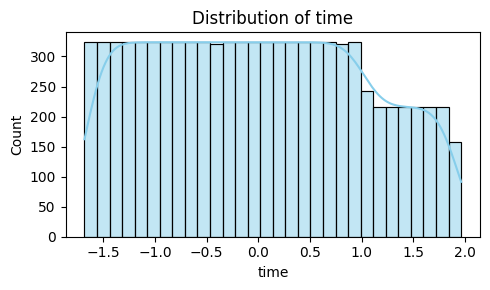

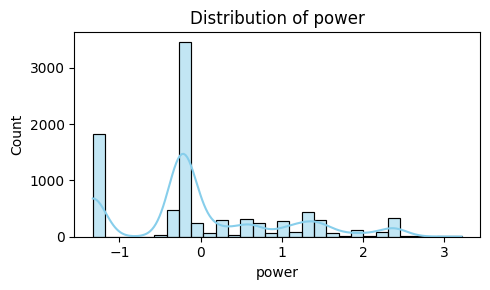

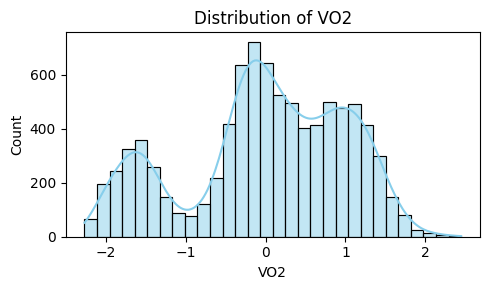

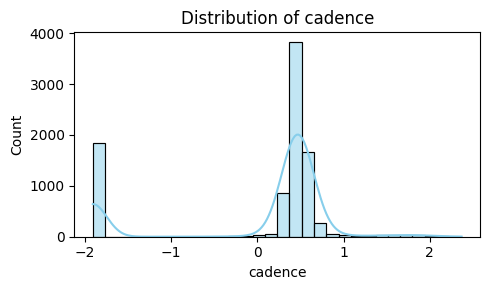

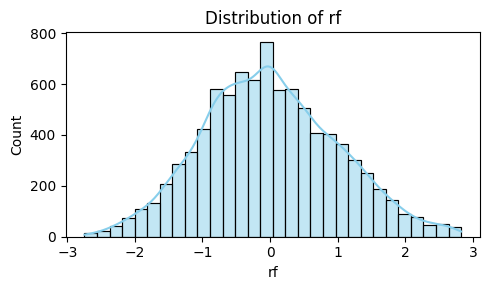

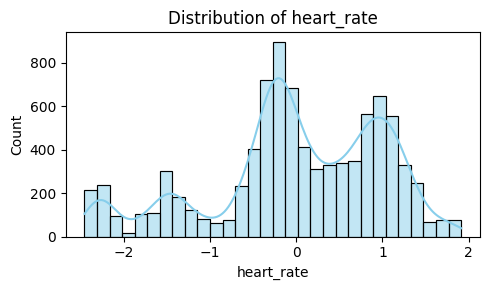

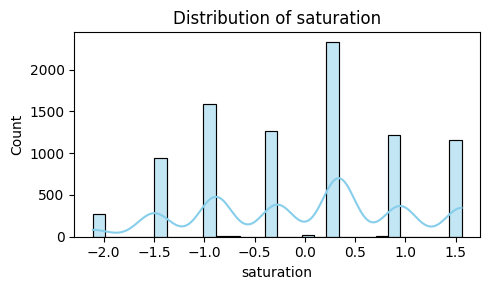

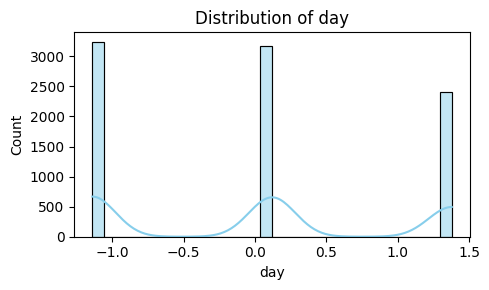

In [ ]:
for col in X.columns:
    if col == "const":
        continue
    plt.figure(figsize=(5, 3))
    sns.histplot(X[col], bins=30, kde=True, color="skyblue")
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    plt.show()


3. Linearity & Homoscedasticity — Residuals vs Fitted

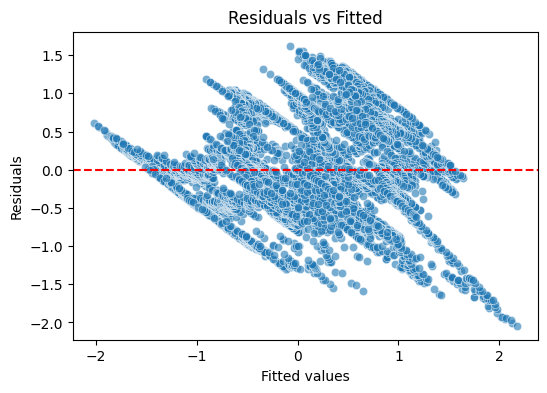

In [ ]:
plt.figure(figsize=(6, 4))
sns.scatterplot(x=fitted, y=residuals, alpha=0.6)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted")
plt.show()


4. Normality of Residuals — Q-Q Plot

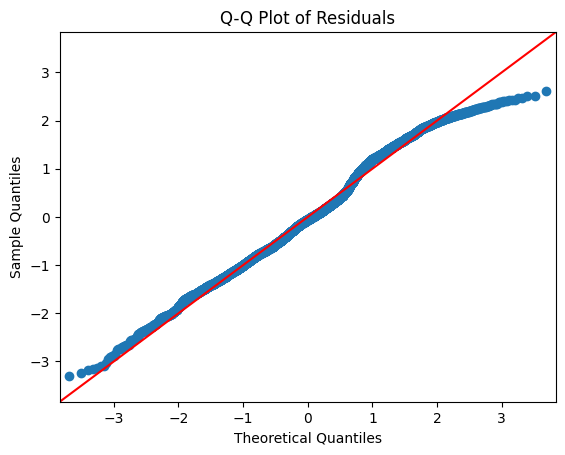

Shapiro-Wilk p-value: 3.1049935984228906e-25


/Users/evaharris/Desktop/Classes/CS109a/CS109A---Final-Project-Blood-Lactate-Analysis/.venv/lib/python3.11/site-packages/scipy/stats/_axis_nan_policy.py:579: UserWarning: scipy.stats.shapiro: For N > 5000, computed p-value may not be accurate. Current N is 8818.
  res = hypotest_fun_out(*samples, **kwds)


In [ ]:
sm.qqplot(residuals, line="45", fit=True)
plt.title("Q-Q Plot of Residuals")
plt.show()

# Shapiro–Wilk Test for Normaility as well -- p > 0.5 is usually good
stat, p = stats.shapiro(residuals)
print("Shapiro-Wilk p-value:", p)


5. Independence — Residuals vs Time (or Duration)

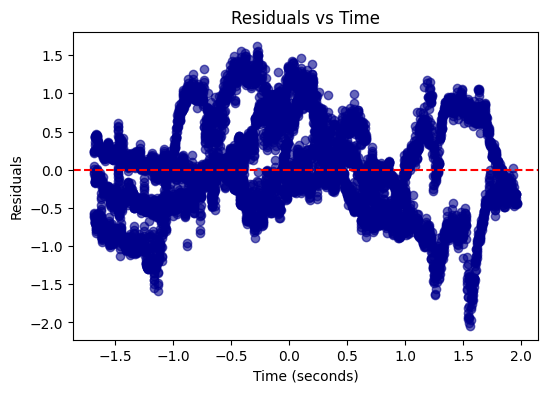

In [ ]:
plt.figure(figsize=(6, 4))
plt.scatter(df["time"], residuals, alpha=0.6, color="darkblue")
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("Time (seconds)")
plt.ylabel("Residuals")
plt.title("Residuals vs Time")
plt.show()


6. Residual Histogram

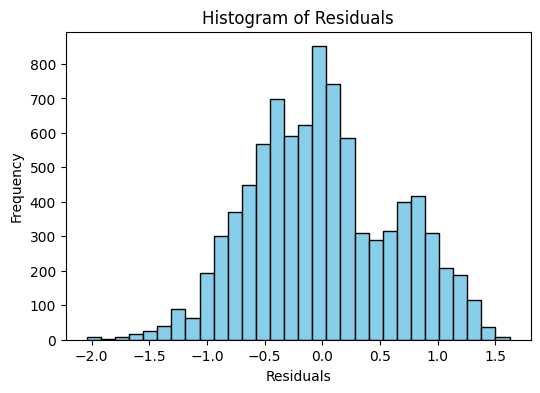

In [ ]:
plt.figure(figsize=(6, 4))
plt.hist(residuals, bins=30, color="skyblue", edgecolor="black")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Histogram of Residuals")
plt.show()


## 5 - Prediction


 (or Classification -- TBD)

### Baseline
### LASSO
### RIDGE
### Random Forest